# Peer Selection Pattern Analysis

This notebook analyzes **longitudinal patterns** in peer selection behavior for agent_0.

**Research Questions:**
1. **Peer Preference Persistence**: Does agent_0 repeatedly select the same peers within an episode?
2. **Reciprocity Learning**: Does agent_0 learn to prefer peers who also select them?
3. **Temporal Evolution**: Do these patterns change over training time?

**Key Metrics:**
- **Repeat Selection Rate**: Fraction of peer selections that are re-selections of previously chosen peers
- **Reciprocity Score**: Correlation between "peer selects me" and "I select peer"
- **Peer Diversity**: Number of unique peers selected per episode
- **Mutual Selection Rate**: Fraction of collaborations that are bidirectional

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Set
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Data Loading Functions

**Data Structure:**
- `peer_group[i]` = 1 means agent `i` is available, 0 means not available
- `collaborate_with[i]` = 1 means agent_0 selected agent `i`, 0 means not selected
- Peer IDs are **implicitly** the index in these arrays

In [2]:
def load_episode_selections(actions_path, observations_path, target_agent='agent_0'):
    """
    Load peer selection data for one episode.
    
    Returns:
    - selections: list of dicts with timestep info
    - all_selections: dict mapping timestep -> agent_id -> list of selected peer IDs
    """
    actions_path = Path(actions_path)
    observations_path = Path(observations_path)
    
    target_selections = []  # For target agent only
    all_selections = defaultdict(dict)  # For all agents (reciprocity)
    
    with open(actions_path, 'r') as f_act, open(observations_path, 'r') as f_obs:
        timestep = 0
        for line_act, line_obs in zip(f_act, f_obs):
            try:
                action_data = json.loads(line_act)
                obs_data = json.loads(line_obs)
                
                # Process target agent (agent_0)
                if target_agent in action_data and target_agent in obs_data:
                    agent_action = action_data[target_agent]
                    agent_obs = obs_data[target_agent]
                    
                    # Extract observation
                    if 'observation' in agent_obs:
                        obs = agent_obs['observation']
                    else:
                        obs = agent_obs
                    
                    # Get available peers (peer_group[i] = 1 means available)
                    peer_group = obs.get('peer_group', [])
                    available_peer_ids = [i for i, avail in enumerate(peer_group) if avail == 1]
                    
                    # Get collaboration action
                    if isinstance(agent_action, dict):
                        collab_action = agent_action.get('collaborate_with', [])
                    else:
                        collab_action = []
                    
                    # Get selected peers (collaborate_with[i] = 1 means selected)
                    selected_peer_ids = [i for i, sel in enumerate(collab_action) if sel == 1]
                    
                    target_selections.append({
                        'timestep': timestep,
                        'selected_peer_ids': selected_peer_ids,
                        'available_peer_ids': available_peer_ids,
                        'n_selected': len(selected_peer_ids),
                        'n_available': len(available_peer_ids),
                    })
                
                # Process ALL agents for reciprocity analysis
                for agent_id_str, agent_action in action_data.items():
                    if agent_action is None:
                        continue
                    
                    # Extract agent index from "agent_X" string
                    try:
                        agent_idx = int(agent_id_str.split('_')[1])
                    except (IndexError, ValueError):
                        continue
                    
                    # Get collaboration action
                    if isinstance(agent_action, dict):
                        collab_action = agent_action.get('collaborate_with', [])
                    else:
                        collab_action = []
                    
                    # Get selected peers
                    selected_peer_ids = [i for i, sel in enumerate(collab_action) if sel == 1]
                    all_selections[timestep][agent_idx] = selected_peer_ids
                
                timestep += 1
                
            except (json.JSONDecodeError, KeyError, ValueError, IndexError, TypeError) as e:
                timestep += 1
                continue
    
    return target_selections, dict(all_selections)

## Metric Computation Functions

In [3]:
def compute_repeat_selection_rate(selections: List[Dict]) -> Dict:
    """
    Compute how often agent_0 re-selects peers they've selected before.
    """
    seen_peers = set()
    total_selections = 0
    repeat_selections = 0
    peer_counts = Counter()
    
    for step in selections:
        for peer_id in step['selected_peer_ids']:
            total_selections += 1
            peer_counts[peer_id] += 1
            
            if peer_id in seen_peers:
                repeat_selections += 1
            else:
                seen_peers.add(peer_id)
    
    repeat_rate = repeat_selections / total_selections if total_selections > 0 else 0.0
    
    return {
        'repeat_rate': repeat_rate,
        'n_unique_peers': len(seen_peers),
        'n_total_selections': total_selections,
        'repeat_selections': repeat_selections,
        'peer_counts': dict(peer_counts),
    }


def compute_reciprocity_metrics(selections: List[Dict], all_selections: Dict, agent_0_id=0) -> Dict:
    """
    Compute reciprocity metrics: does agent_0 prefer peers who select them?
    """
    # Track mutual selections
    mutual_selections = 0
    total_agent0_selections = 0
    
    # Who selected agent_0 across all timesteps
    who_selected_agent0 = set()
    
    for step_data in selections:
        timestep = step_data['timestep']
        agent0_selected = set(step_data['selected_peer_ids'])
        
        if timestep in all_selections:
            # Check each peer agent_0 selected
            for peer_id in agent0_selected:
                total_agent0_selections += 1
                
                # Did this peer also select agent_0?
                if peer_id in all_selections[timestep]:
                    peer_selections = all_selections[timestep][peer_id]
                    if agent_0_id in peer_selections:
                        mutual_selections += 1
                        who_selected_agent0.add(peer_id)
    
    mutual_rate = mutual_selections / total_agent0_selections if total_agent0_selections > 0 else 0.0
    
    return {
        'mutual_selection_rate': mutual_rate,
        'mutual_selections': mutual_selections,
        'total_selections': total_agent0_selections,
        'n_agents_who_selected_agent0': len(who_selected_agent0),
    }


def compute_peer_diversity(selections: List[Dict]) -> Dict:
    """
    Compute diversity metrics: how many different peers does agent_0 select?
    """
    unique_peers_selected = set()
    total_available_peers = set()
    
    for step in selections:
        unique_peers_selected.update(step['selected_peer_ids'])
        total_available_peers.update(step['available_peer_ids'])
    
    diversity_rate = len(unique_peers_selected) / len(total_available_peers) if len(total_available_peers) > 0 else 0.0
    
    return {
        'n_unique_peers_selected': len(unique_peers_selected),
        'n_total_available_peers': len(total_available_peers),
        'diversity_rate': diversity_rate,
    }


def compute_temporal_patterns(selections: List[Dict]) -> Dict:
    """
    Analyze how selection patterns change over the episode.
    """
    if len(selections) == 0:
        return {}
    
    # Split episode into early, mid, late thirds
    n_steps = len(selections)
    third = max(n_steps // 3, 1)
    
    early = selections[:third]
    mid = selections[third:2*third]
    late = selections[2*third:]
    
    def get_unique_peers(subset):
        peers = set()
        for step in subset:
            peers.update(step['selected_peer_ids'])
        return len(peers)
    
    return {
        'early_unique_peers': get_unique_peers(early),
        'mid_unique_peers': get_unique_peers(mid),
        'late_unique_peers': get_unique_peers(late),
    }

## Load All Episodes

In [4]:
def load_all_episodes(base_dir='../output_jsons/ppo'):
    """
    Load peer selection patterns from all episodes.
    
    Returns: DataFrame with one row per episode
    """
    base_path = Path(base_dir)
    subdirs = sorted([d for d in base_path.iterdir() if d.is_dir()])
    
    print(f"Found {len(subdirs)} subdirectories")
    
    results = []
    
    for subdir in subdirs:
        # Extract seed from directory name
        import re
        match = re.search(r's(\d+)', subdir.name)
        seed = int(match.group(1)) if match else None
        
        actions_files = list(subdir.glob('*_actions.jsonl'))
        obs_files = list(subdir.glob('*_observations.jsonl'))
        
        if not actions_files or not obs_files:
            continue
        
        actions_path = actions_files[0]
        obs_path = obs_files[0]
        
        print(f"Processing {subdir.name}...", end=" ")
        
        try:
            # Load selections
            selections, all_selections = load_episode_selections(actions_path, obs_path)
            
            if len(selections) == 0:
                print("no data")
                continue
            
            # Compute metrics
            repeat_metrics = compute_repeat_selection_rate(selections)
            reciprocity_metrics = compute_reciprocity_metrics(selections, all_selections)
            diversity_metrics = compute_peer_diversity(selections)
            temporal_metrics = compute_temporal_patterns(selections)
            
            # Combine all metrics
            episode_data = {
                'run_id': subdir.name,
                'seed': seed,
                'n_timesteps': len(selections),
                **repeat_metrics,
                **reciprocity_metrics,
                **diversity_metrics,
                **temporal_metrics,
            }
            
            results.append(episode_data)
            
            print(f"repeat={repeat_metrics['repeat_rate']:.3f}, mutual={reciprocity_metrics['mutual_selection_rate']:.3f}")
            
        except Exception as e:
            print(f"ERROR: {e}")
            continue
    
    df = pd.DataFrame(results)
    print(f"\nLoaded {len(df)} episodes")
    return df


# Load data
df_episodes = load_all_episodes('../output_jsons/ppo')
df_episodes.head()

Found 100 subdirectories
Processing rl_ppo_by_effort_s501_20260514_124852_s501... repeat=0.960, mutual=0.863
Processing rl_ppo_by_effort_s501_20260514_144156_s501... repeat=0.970, mutual=0.895
Processing rl_ppo_by_effort_s501_20260514_154929_s501... repeat=0.965, mutual=0.911
Processing rl_ppo_by_effort_s501_20260514_165637_s501... repeat=0.974, mutual=0.897
Processing rl_ppo_by_effort_s501_20260514_201037_s501... repeat=0.971, mutual=0.942
Processing rl_ppo_by_effort_s502_20260514_125229_s502... repeat=0.993, mutual=0.357
Processing rl_ppo_by_effort_s502_20260514_144500_s502... repeat=0.989, mutual=0.381
Processing rl_ppo_by_effort_s502_20260514_155241_s502... repeat=0.989, mutual=0.459
Processing rl_ppo_by_effort_s502_20260514_165943_s502... repeat=0.992, mutual=0.336
Processing rl_ppo_by_effort_s502_20260514_201307_s502... repeat=0.985, mutual=0.409
Processing rl_ppo_by_effort_s503_20260514_125604_s503... repeat=0.970, mutual=0.813
Processing rl_ppo_by_effort_s503_20260514_144812_s5

,run_id,seed,n_timesteps,repeat_rate,n_unique_peers,n_total_selections,repeat_selections,peer_counts,mutual_selection_rate,mutual_selections,total_selections,n_agents_who_selected_agent0,n_unique_peers_selected,n_total_available_peers,diversity_rate,early_unique_peers,mid_unique_peers,late_unique_peers
0,rl_ppo_by_effort_s501_20260514_124852_s501,501,72,0.960366,13,328,315,"{1: 1, 5: 68, 6: 61, 7: 11, 8: 29, 9: 24, 2: 1...",0.862805,283,328,11,13,14,0.928571,10,7,11
1,rl_ppo_by_effort_s501_20260514_144156_s501,501,73,0.969626,13,428,415,"{1: 8, 2: 47, 3: 28, 7: 50, 8: 70, 9: 32, 5: 3...",0.894860,383,428,11,13,16,0.812500,11,10,12
2,rl_ppo_by_effort_s501_20260514_154929_s501,501,74,0.965054,13,372,359,"{1: 11, 2: 73, 3: 14, 4: 27, 5: 56, 6: 5, 7: 3...",0.911290,339,372,11,13,14,0.928571,9,9,9
3,rl_ppo_by_effort_s501_20260514_165637_s501,501,76,0.974257,13,505,492,"{2: 64, 3: 73, 4: 57, 5: 17, 6: 75, 7: 73, 8: ...",0.897030,453,505,10,13,13,1.000000,10,9,11
4,rl_ppo_by_effort_s501_20260514_201037_s501,501,75,0.970852,13,446,433,"{0: 25, 1: 6, 2: 25, 3: 36, 4: 9, 5: 71, 6: 57...",0.941704,420,446,11,13,14,0.928571,10,7,12


## Summary Statistics

In [5]:
print("="*80)
print("PEER SELECTION PATTERN SUMMARY")
print("="*80)
print()

# Overall statistics
print(f"Total episodes: {len(df_episodes)}")
print(f"Total seeds: {df_episodes['seed'].nunique()}")
print()

# Repeat selection rate
print("REPEAT SELECTION RATE (Does agent_0 re-select same peers?)")
print(f"  Mean: {df_episodes['repeat_rate'].mean():.3f}")
print(f"  Std:  {df_episodes['repeat_rate'].std():.3f}")
print(f"  Min:  {df_episodes['repeat_rate'].min():.3f}")
print(f"  Max:  {df_episodes['repeat_rate'].max():.3f}")
print()

# Mutual selection rate (reciprocity)
print("MUTUAL SELECTION RATE (Do selected peers also select agent_0?)")
print(f"  Mean: {df_episodes['mutual_selection_rate'].mean():.3f}")
print(f"  Std:  {df_episodes['mutual_selection_rate'].std():.3f}")
print(f"  Min:  {df_episodes['mutual_selection_rate'].min():.3f}")
print(f"  Max:  {df_episodes['mutual_selection_rate'].max():.3f}")
print()

# Diversity
print("PEER DIVERSITY")
print(f"  Mean unique peers selected: {df_episodes['n_unique_peers'].mean():.1f}")
print(f"  Mean diversity rate: {df_episodes['diversity_rate'].mean():.3f}")
print(f"  (diversity_rate = unique_selected / total_available)")
print()

# Display distribution
df_episodes[['repeat_rate', 'mutual_selection_rate', 'diversity_rate', 'n_unique_peers']].describe()

PEER SELECTION PATTERN SUMMARY

Total episodes: 100
Total seeds: 20

REPEAT SELECTION RATE (Does agent_0 re-select same peers?)
  Mean: 0.980
  Std:  0.009
  Min:  0.953
  Max:  0.994

MUTUAL SELECTION RATE (Do selected peers also select agent_0?)
  Mean: 0.676
  Std:  0.214
  Min:  0.220
  Max:  0.995

PEER DIVERSITY
  Mean unique peers selected: 21.5
  Mean diversity rate: 0.958
  (diversity_rate = unique_selected / total_available)



,repeat_rate,mutual_selection_rate,diversity_rate,n_unique_peers
count,100.000000,100.000000,100.000000,100.000000
mean,0.979905,0.676319,0.958016,21.540000
std,0.009493,0.213675,0.048727,10.320539
min,0.952991,0.220359,0.800000,10.000000
25%,0.972653,0.458420,0.928571,13.000000
50%,0.981019,0.734810,0.969223,16.000000
75%,0.988638,0.853001,1.000000,31.250000
max,0.994190,0.994819,1.000000,39.000000


## By-Seed Analysis

In [6]:
# Group by seed to see if patterns differ across environments
seed_summary = df_episodes.groupby('seed').agg({
    'repeat_rate': ['mean', 'std', 'count'],
    'mutual_selection_rate': ['mean', 'std'],
    'diversity_rate': ['mean', 'std'],
    'n_unique_peers': ['mean', 'std'],
}).round(3)

print("="*80)
print("BY-SEED ANALYSIS")
print("="*80)
seed_summary

BY-SEED ANALYSIS


repeat_rate              mutual_selection_rate        diversity_rate  \
            mean    std count                  mean    std           mean   
seed                                                                        
501        0.968  0.005     5                 0.902  0.029          0.920   
502        0.990  0.003     5                 0.388  0.048          0.962   
503        0.975  0.003     5                 0.836  0.016          0.961   
504        0.981  0.001     5                 0.818  0.030          0.967   
505        0.985  0.008     5                 0.795  0.158          0.955   
506        0.969  0.003     5                 0.835  0.024          0.958   
507        0.978  0.008     5                 0.729  0.103          0.986   
508        0.989  0.002     5                 0.374  0.122          0.962   
509        0.978  0.004     5                 0.854  0.077          1.000   
510        0.985  0.008     5                 0.393  0.149          0.973   
511        0.985  0.013     5                 0.525  0.157          0.990   
512        0.967  0.008     5                 0.807  0.095          0.933   
513        0.981  0.005     5                 0.723  0.138          0.986   
514        0.979  0.011     5                 0.734  0.217          0.974   
515        0.983  0.010     5                 0.607  0.162          0.977   
516        0.986  0.006     5                 0.588  0.197          0.969   
517        0.989  0.002     5                 0.412  0.028          0.941   
518        0.977  0.006     5                 0.876  0.089          0.939   
519        0.968  0.005     5                 0.874  0.037          0.857   
520        0.985  0.008     5                 0.456  0.144          0.950   

            n_unique_peers          
        std           mean     std  
seed                                
501   0.067           13.0   0.000  
502   0.027           29.0   4.796  
503   0.059           14.6   1.140  
504   0.048           16.4   0.548  
505   0.031           21.0   8.573  
506   0.038           13.6   0.548  
507   0.032           14.8   2.049  
508   0.028           30.2   8.899  
509   0.000           12.6   1.817  
510   0.019           31.4  10.455  
511   0.022           26.0  10.794  
512   0.070           11.2   0.837  
513   0.032           15.4   2.702  
514   0.026           27.0  14.646  
515   0.023           28.2  10.710  
516   0.028           30.2  11.077  
517   0.023           34.8   3.962  
518   0.077           15.4   1.517  
519   0.068           13.0   1.414  
520   0.024           33.0  11.225

## Visualizations

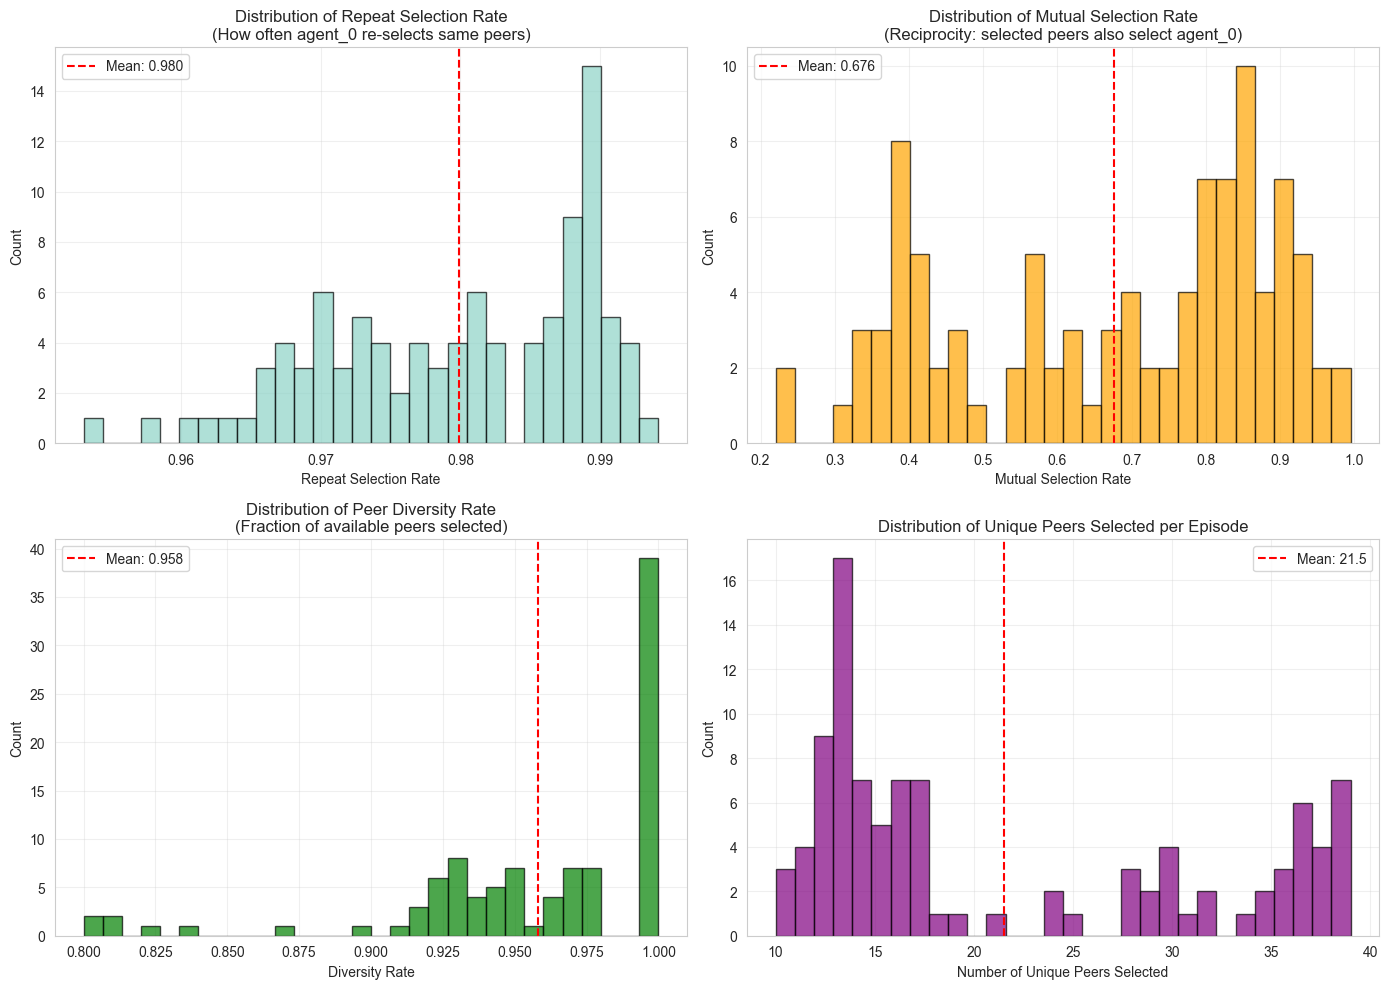

In [7]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Repeat rate
axes[0, 0].hist(df_episodes['repeat_rate'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_episodes['repeat_rate'].mean(), color='red', linestyle='--', label=f"Mean: {df_episodes['repeat_rate'].mean():.3f}")
axes[0, 0].set_xlabel('Repeat Selection Rate')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Repeat Selection Rate\n(How often agent_0 re-selects same peers)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Mutual selection rate
axes[0, 1].hist(df_episodes['mutual_selection_rate'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].axvline(df_episodes['mutual_selection_rate'].mean(), color='red', linestyle='--', label=f"Mean: {df_episodes['mutual_selection_rate'].mean():.3f}")
axes[0, 1].set_xlabel('Mutual Selection Rate')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of Mutual Selection Rate\n(Reciprocity: selected peers also select agent_0)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Diversity rate
axes[1, 0].hist(df_episodes['diversity_rate'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].axvline(df_episodes['diversity_rate'].mean(), color='red', linestyle='--', label=f"Mean: {df_episodes['diversity_rate'].mean():.3f}")
axes[1, 0].set_xlabel('Diversity Rate')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Distribution of Peer Diversity Rate\n(Fraction of available peers selected)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Number of unique peers
axes[1, 1].hist(df_episodes['n_unique_peers'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].axvline(df_episodes['n_unique_peers'].mean(), color='red', linestyle='--', label=f"Mean: {df_episodes['n_unique_peers'].mean():.1f}")
axes[1, 1].set_xlabel('Number of Unique Peers Selected')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Distribution of Unique Peers Selected per Episode')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

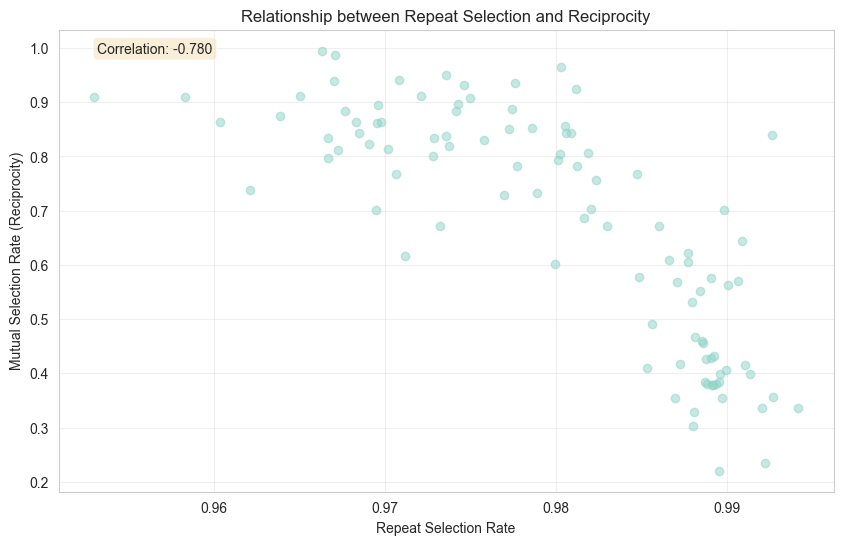

Correlation between repeat_rate and mutual_selection_rate: -0.780


In [8]:
# Scatter plot: repeat rate vs mutual selection rate
plt.figure(figsize=(10, 6))
plt.scatter(df_episodes['repeat_rate'], df_episodes['mutual_selection_rate'], alpha=0.5)
plt.xlabel('Repeat Selection Rate')
plt.ylabel('Mutual Selection Rate (Reciprocity)')
plt.title('Relationship between Repeat Selection and Reciprocity')
plt.grid(alpha=0.3)

# Add correlation
corr = df_episodes['repeat_rate'].corr(df_episodes['mutual_selection_rate'])
plt.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.show()

print(f"Correlation between repeat_rate and mutual_selection_rate: {corr:.3f}")

## Temporal Evolution Analysis

Check if patterns change from early to late in episodes

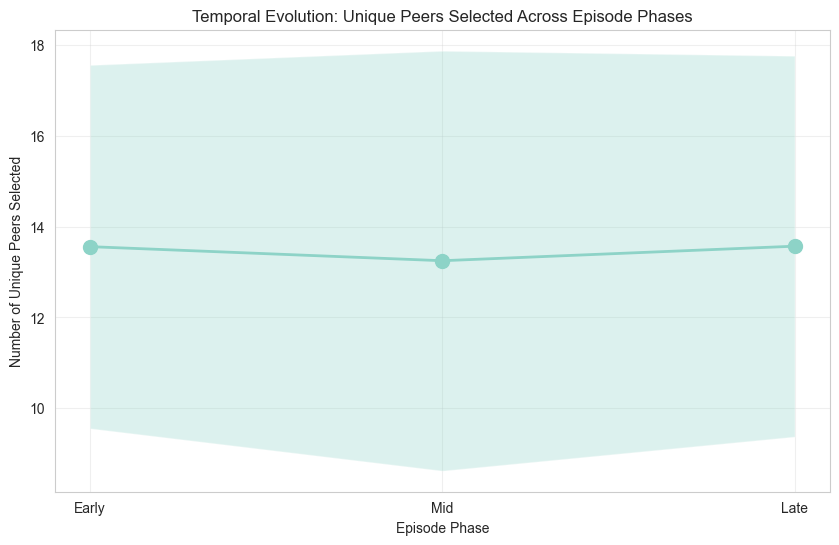

Temporal evolution of unique peers:
  Early: 13.56 ± 4.00
  Mid: 13.25 ± 4.63
  Late: 13.57 ± 4.20


In [9]:
# Plot temporal evolution of unique peers
temporal_cols = ['early_unique_peers', 'mid_unique_peers', 'late_unique_peers']
if all(col in df_episodes.columns for col in temporal_cols):
    temporal_means = df_episodes[temporal_cols].mean()
    temporal_stds = df_episodes[temporal_cols].std()
    
    plt.figure(figsize=(10, 6))
    x = ['Early', 'Mid', 'Late']
    plt.plot(x, temporal_means.values, marker='o', linewidth=2, markersize=10)
    plt.fill_between(range(3), 
                     temporal_means.values - temporal_stds.values,
                     temporal_means.values + temporal_stds.values,
                     alpha=0.3)
    plt.xlabel('Episode Phase')
    plt.ylabel('Number of Unique Peers Selected')
    plt.title('Temporal Evolution: Unique Peers Selected Across Episode Phases')
    plt.grid(alpha=0.3)
    plt.show()
    
    print("Temporal evolution of unique peers:")
    for phase, mean, std in zip(x, temporal_means.values, temporal_stds.values):
        print(f"  {phase}: {mean:.2f} ± {std:.2f}")

## Interpretation & Insights

In [10]:
print("="*80)
print("KEY INSIGHTS")
print("="*80)
print()

mean_repeat = df_episodes['repeat_rate'].mean()
mean_mutual = df_episodes['mutual_selection_rate'].mean()
mean_diversity = df_episodes['diversity_rate'].mean()

print(f"1. PEER LOYALTY (Repeat Selection Rate = {mean_repeat:.3f})")
if mean_repeat > 0.5:
    print("   -> Agent_0 shows HIGH peer loyalty, frequently re-selecting same peers")
elif mean_repeat > 0.3:
    print("   -> Agent_0 shows MODERATE peer loyalty")
else:
    print("   -> Agent_0 shows LOW peer loyalty, explores diverse collaborations")
print()

print(f"2. RECIPROCITY LEARNING (Mutual Selection Rate = {mean_mutual:.3f})")
if mean_mutual > 0.6:
    print("   -> Agent_0 STRONGLY prefers peers who also select them (high reciprocity)")
elif mean_mutual > 0.4:
    print("   -> Agent_0 shows MODERATE reciprocity preference")
else:
    print("   -> Agent_0 shows LOW reciprocity (selections not driven by mutual interest)")
print()

print(f"3. EXPLORATION vs EXPLOITATION (Diversity Rate = {mean_diversity:.3f})")
if mean_diversity > 0.7:
    print("   -> Agent_0 EXPLORES broadly, collaborating with many different peers")
elif mean_diversity > 0.5:
    print("   -> Agent_0 balances exploration and exploitation")
else:
    print("   -> Agent_0 EXPLOITS narrow set of peers, focused collaboration")
print()

print("="*80)

KEY INSIGHTS

1. PEER LOYALTY (Repeat Selection Rate = 0.980)
   -> Agent_0 shows HIGH peer loyalty, frequently re-selecting same peers

2. RECIPROCITY LEARNING (Mutual Selection Rate = 0.676)
   -> Agent_0 STRONGLY prefers peers who also select them (high reciprocity)

3. EXPLORATION vs EXPLOITATION (Diversity Rate = 0.958)
   -> Agent_0 EXPLORES broadly, collaborating with many different peers



## Export Results

In [11]:
# Save summary statistics
output_dir = Path('../analysis')
output_dir.mkdir(exist_ok=True)

# Save full episode data
df_episodes.to_csv(output_dir / 'peer_selection_patterns.csv', index=False)
print(f"Saved episode-level data to {output_dir / 'peer_selection_patterns.csv'}")

# Save seed-level summary
seed_summary.to_csv(output_dir / 'peer_selection_by_seed.csv')
print(f"Saved seed-level summary to {output_dir / 'peer_selection_by_seed.csv'}")

Saved episode-level data to ..\analysis\peer_selection_patterns.csv
Saved seed-level summary to ..\analysis\peer_selection_by_seed.csv
